# Практика по Anomaly Detection
-----

## Датасет о Мошенничестве с кредитными картами
Data - `/DATA/credit_card_fraud_10k.csv`

### Features (Informative only)
1. `amount` - Сумма транзакции
2. `transaction_hour` - Час транзакции (0-23)
3. `merchant_category` - Категория магазина (Electronics, Grocery, Travel, Clothing, Food)
4. `foreign_transaction` - Иностранная транзакция (0/1)
5. `location_mismatch` - Несовпадение локации (0/1)
6. `device_trust_score` - Степень доверия к устройству (0-100)
7. `velocity_last_24h` - Количество транзакций за последние 24 часа
8. `cardholder_age` - Возраст держателя карты

### Target
- `is_fraud` - Метка мошенничества (0/1)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Exploratory Data Analysis
---

In [2]:
df = pd.read_csv('~/Downloads/credit_card_fraud_10k.csv')
df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [3]:
'Описательные статистики'
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [4]:
'Сколько мошенников в данных'
df['is_fraud'].value_counts()

is_fraud
0    9849
1     151
Name: count, dtype: int64

In [5]:
print(f'Сколько мошенников в данных - {round(151 / 9849, 4) * 100}%')

Сколько мошенников в данных - 1.53%


### 1.1 Визуализация
---

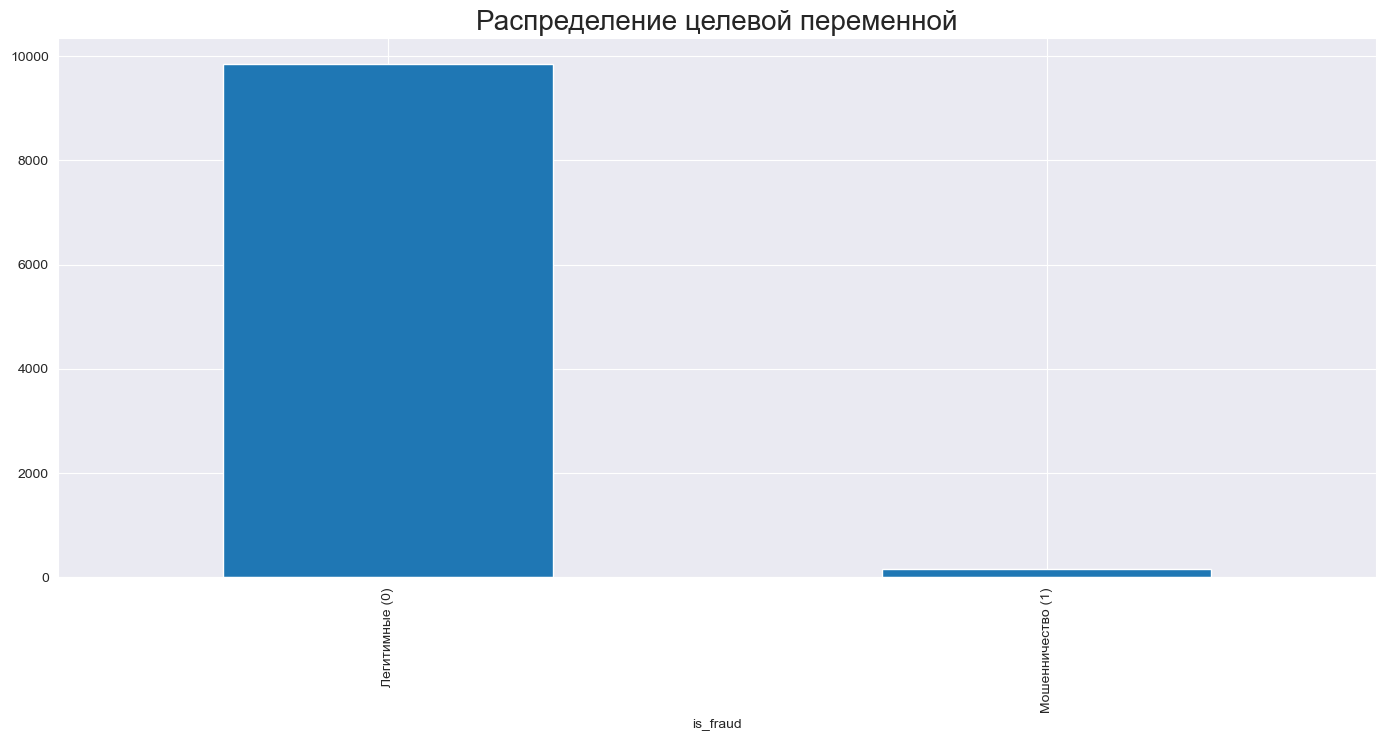

In [6]:
fig, axes = plt.subplots(figsize=(17, 7))

df['is_fraud'].value_counts().plot(kind='bar', ax=axes)
axes.set_title('Распределение целевой переменной', fontsize=20)
axes.set_xticklabels(['Легитимные (0)', 'Мошенничество (1)']);

<Axes: xlabel='cardholder_age', ylabel='amount'>

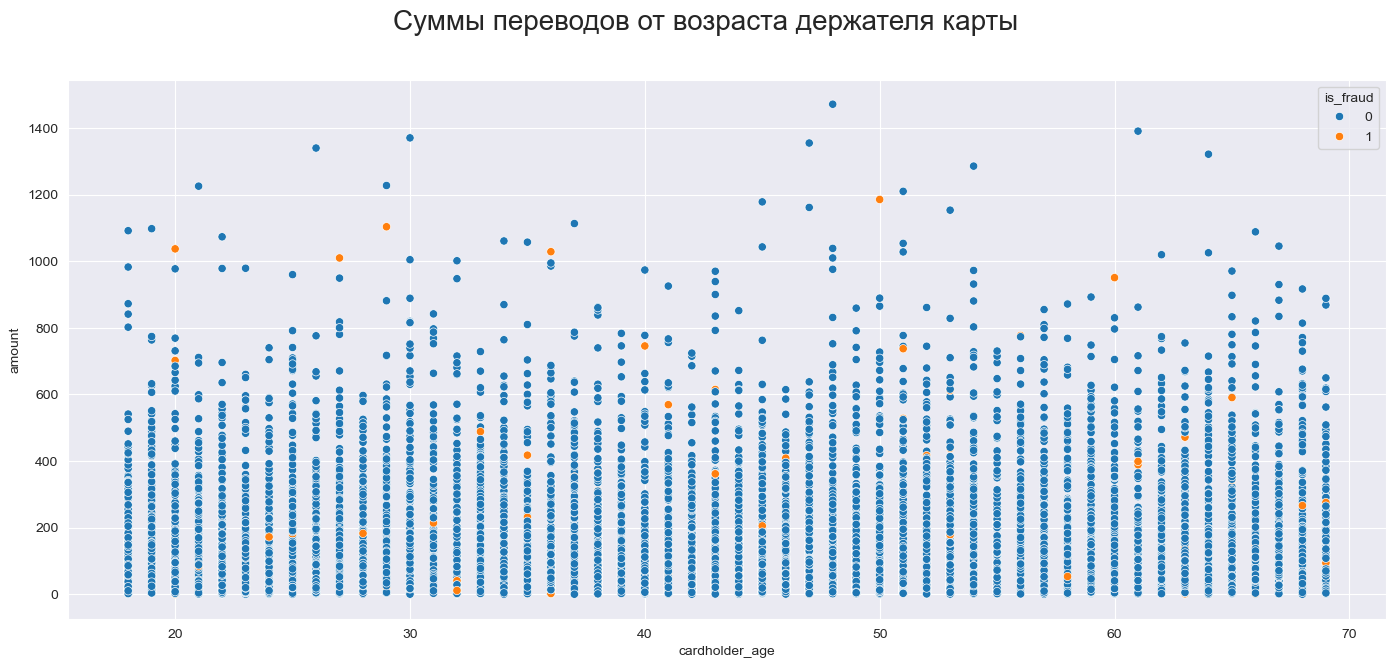

In [7]:
plt.figure(figsize=(17, 7))
plt.suptitle('Суммы переводов от возраста держателя карты', fontsize=20)
sns.scatterplot(data=df, x='cardholder_age', y='amount', hue='is_fraud')

> Значимой корреляции между суммой транзакции и возрастом владельца карты по категории *мошенник* не наблюдается.

<Axes: xlabel='amount', ylabel='Count'>

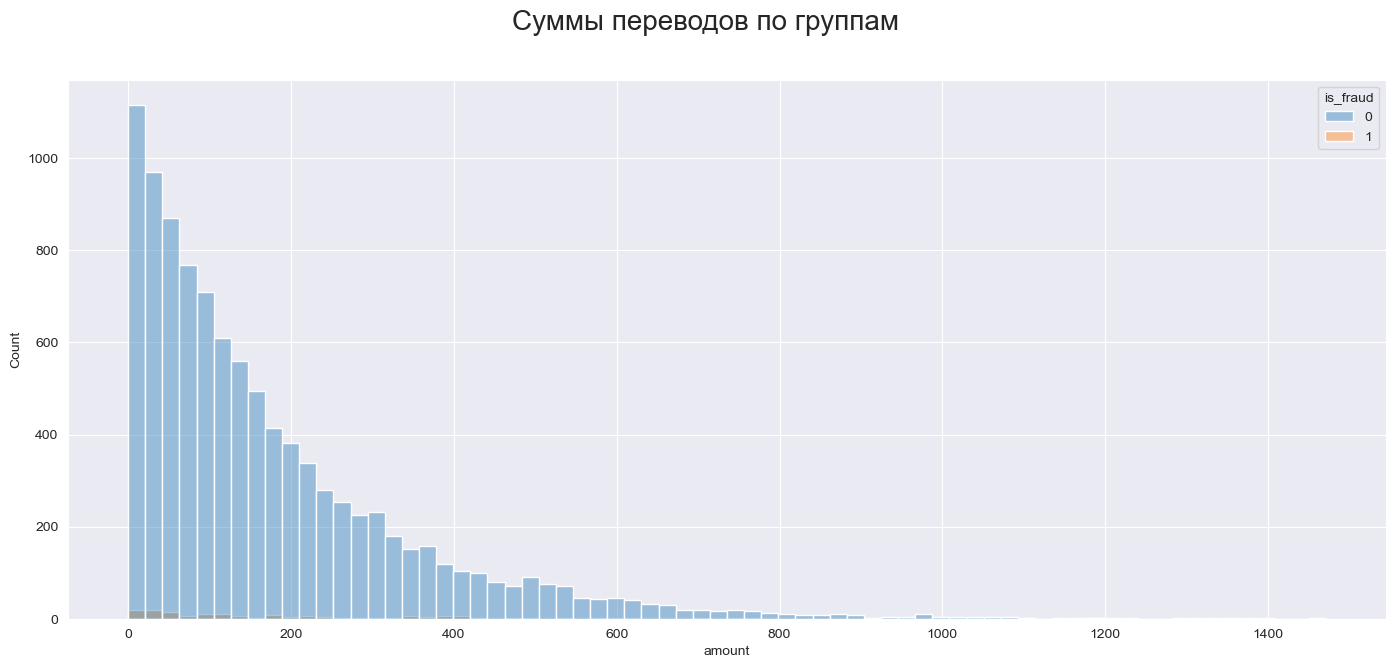

In [8]:
fig, axes = plt.subplots(figsize=(17, 7))

fig.suptitle('Суммы переводов по группам', fontsize=20)
# axes.set_xlim((0, 850))
sns.histplot(data=df, x='amount', hue='is_fraud', bins=70, alpha=0.4)

<Axes: xlabel='amount', ylabel='Count'>

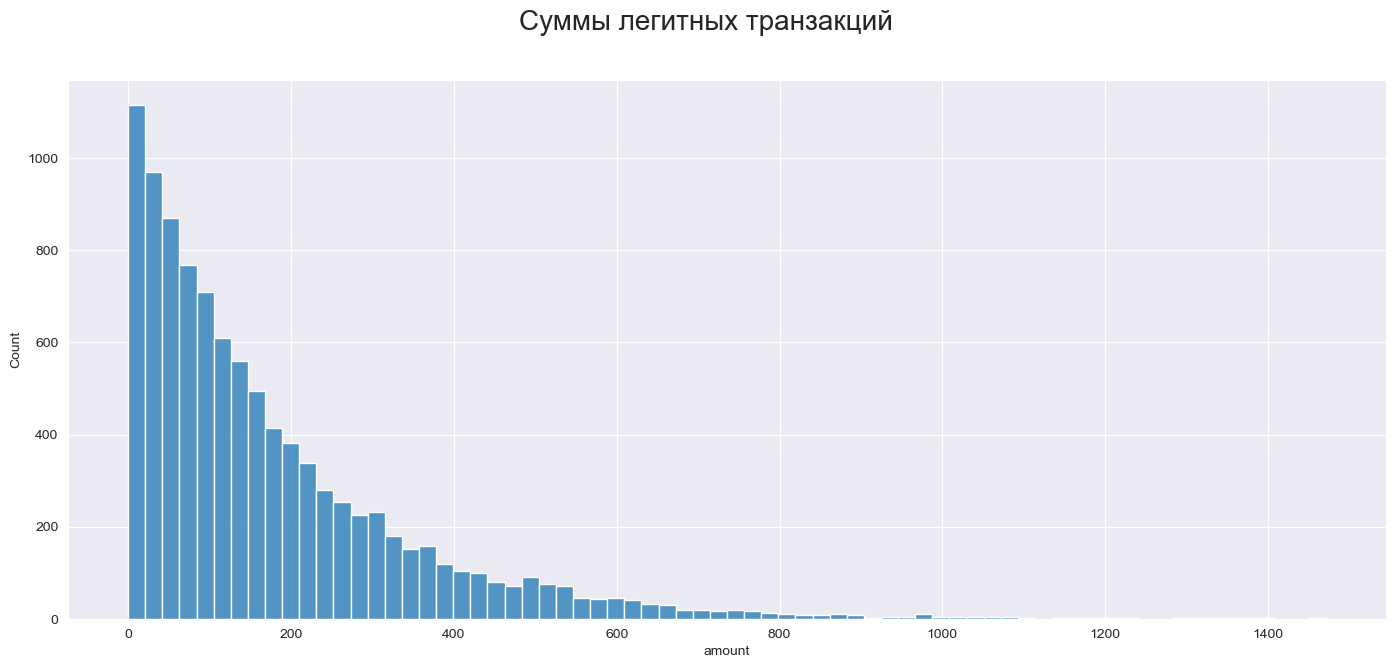

In [9]:
fig, axes = plt.subplots(figsize=(17, 7))

fig.suptitle('Суммы легитных транзакций', fontsize=20)
sns.histplot(data=df[df['is_fraud'] == 0], x='amount', bins=70)

<Axes: xlabel='amount', ylabel='Count'>

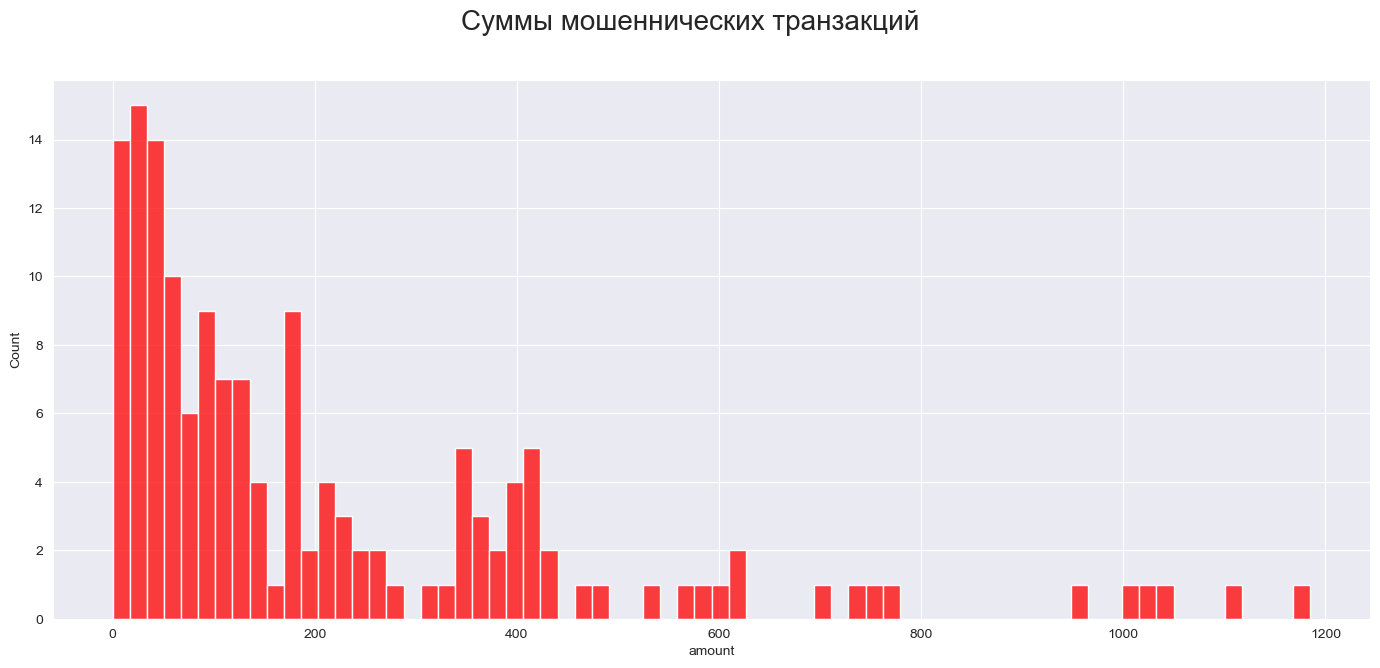

In [10]:
fig, axes = plt.subplots(figsize=(17, 7))

fig.suptitle('Суммы мошеннических транзакций', fontsize=20)
sns.histplot(data=df[df['is_fraud'] > 0], x='amount', color='red', bins=70)

> Большая часть мошеннических транзакций лежит в диапазоне от 0 до 450 у.е.

<Axes: >

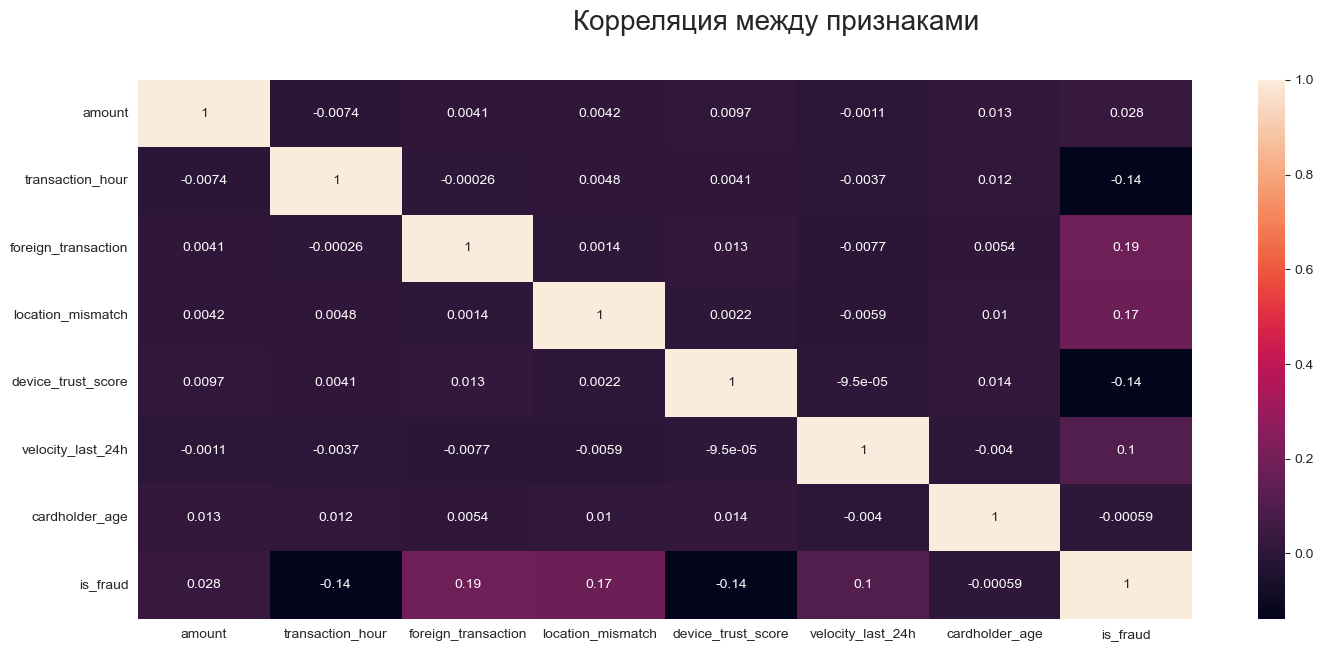

In [11]:
plt.figure(figsize=(17, 7))
plt.suptitle('Корреляция между признаками', fontsize=20)
sns.heatmap(df.drop(['transaction_id', 'merchant_category'], axis=1).corr(), annot=True)

Text(0.5, 1.0, 'Кол-во транзакций (последние 24ч)')

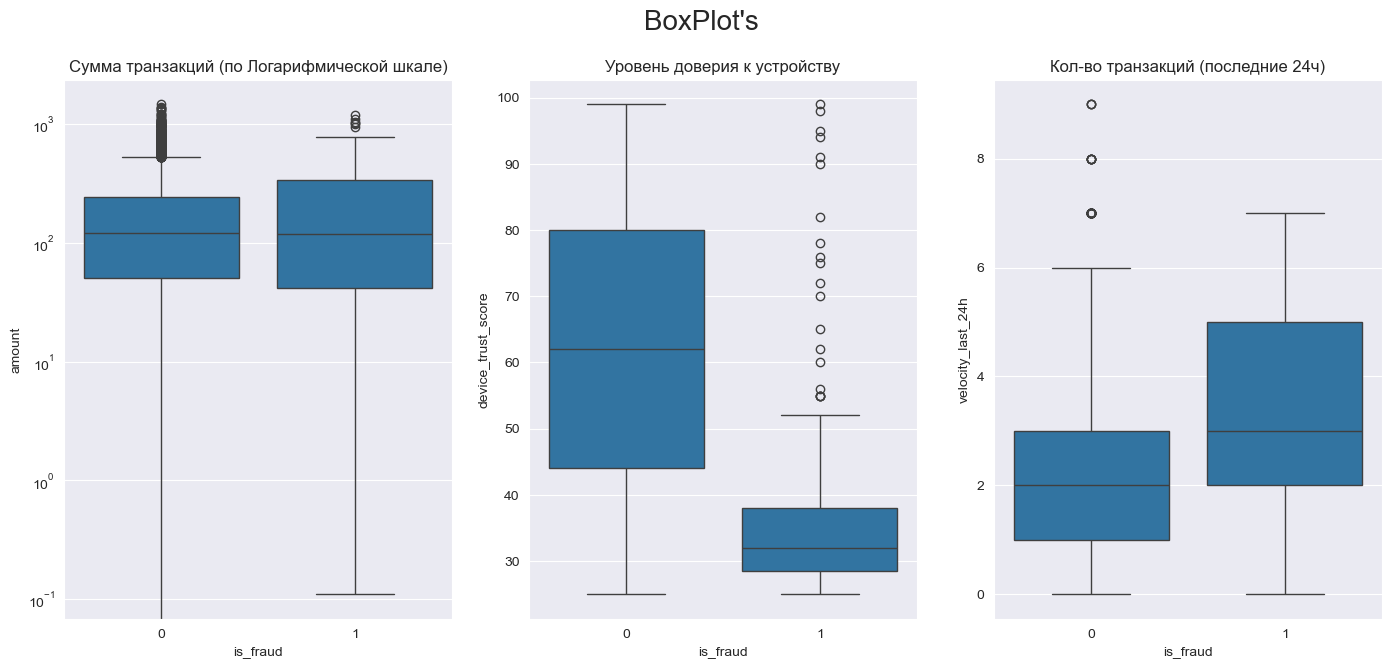

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(17, 7))

fig.suptitle("BoxPlot's", fontsize=20)
sns.boxplot(data=df, x='is_fraud', y='amount', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Сумма транзакций (по Логарифмической шкале)')

sns.boxplot(data=df, x='is_fraud', y='device_trust_score', ax=axes[1])
axes[1].set_title('Уровень доверия к устройству')

sns.boxplot(data=df, x='is_fraud', y='velocity_last_24h', ax=axes[2])
axes[2].set_title('Кол-во транзакций (последние 24ч)')


([<matplotlib.axis.XTick at 0x140f14860>,
 [Text(0, 0, 'Легитимно'), Text(1, 0, 'Мошенничество')])

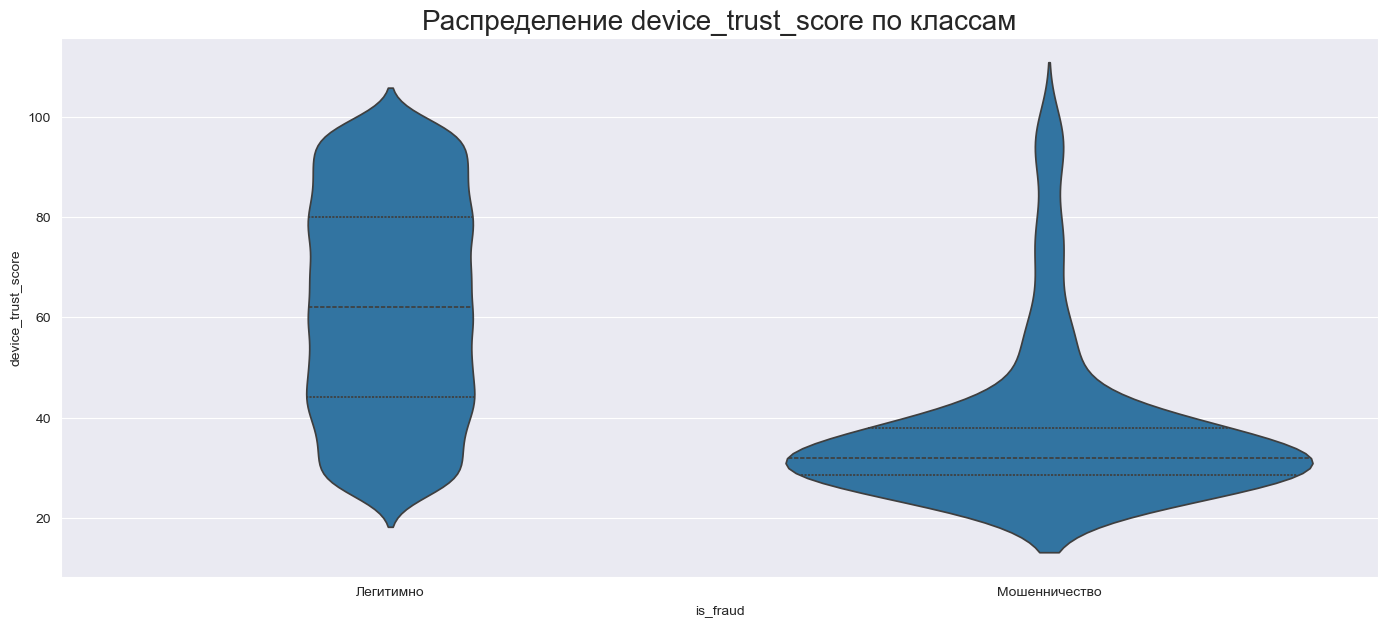

In [13]:
plt.figure(figsize=(17, 7))
sns.violinplot(data=df, x='is_fraud', y='device_trust_score', inner='quartile')
plt.title('Распределение device_trust_score по классам', fontsize=20)
plt.xticks([0, 1], ['Легитимно', 'Мошенничество'])

Text(185.22222222222223, 0.5, 'Час транзакции')

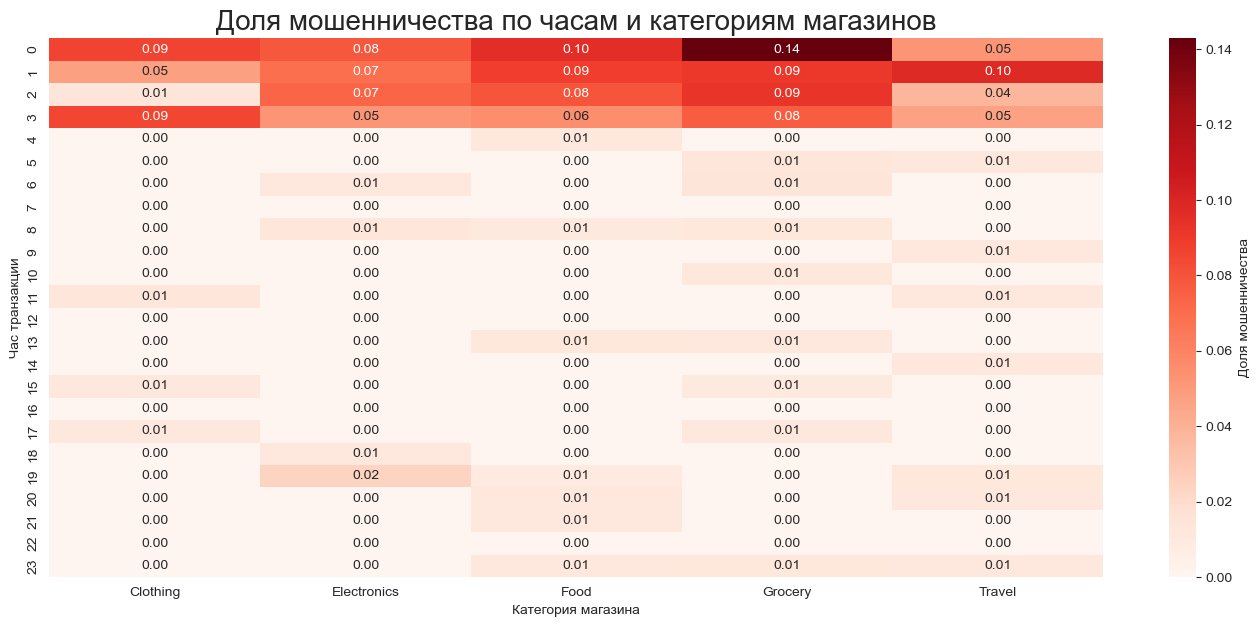

In [14]:
hour_category_fraud = pd.crosstab(
    df['transaction_hour'],
    df['merchant_category'],
    values=df['is_fraud'],
    aggfunc='mean'
)

plt.figure(figsize=(17, 7))
sns.heatmap(hour_category_fraud, cmap='Reds', annot=True, fmt='.2f',
            cbar_kws={'label': 'Доля мошенничества'})
plt.title('Доля мошенничества по часам и категориям магазинов', fontsize=20)
plt.xlabel('Категория магазина')
plt.ylabel('Час транзакции')

## 2.1 Supervised Anomaly Detection
---
При таком подходе мы знаем целевую переменную `is_fraud` = 1. Модель будет обучаться предсказывать метку класса на **размеченных** данных.


**Основная проблема** - Дисбаланс классов. В данных $1.53$% мошенников и $98.47$% нормы. Модель может предсказывать всегда класс 0 с метрикой `Accuracy` = 98.5%, но это не имеет смысла.


Варианты алгоритмов:
1. **Random Forest** - Ансамбль решающих деревьев.
2. **XGBoost/LightGBM** - Деревья строятся независимо, каждое новое дерево учится исправлять ошибки предыдущего.
3. **Logistic Regression** - Базовая классификация.
4. **SVM** - Поиск максимально удаленной гиперплоскости от классов.

> Я буду использовать Логистическую регрессию

### 2.1.1 Обработка данных
> Логарифмирую `amount`, так как в распределении `amount` имеется длинный хвост из больших значений, что может негативно повлиять на результаты модели (Гетероскедастичность).

<Axes: title={'center': 'После логарифма'}, xlabel='amount', ylabel='Count'>

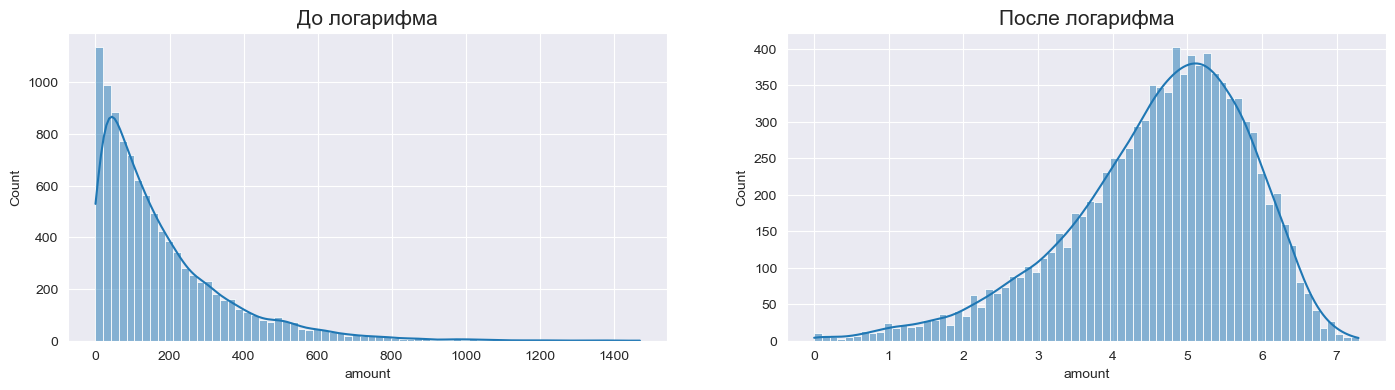

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(17, 4))

axes[0].set_title('До логарифма', fontsize=15)
sns.histplot(data=df, x='amount', bins=70, ax=axes[0], kde=True)

axes[1].set_title('После логарифма', fontsize=15)
sns.histplot(x=np.log1p(df['amount']), bins=70, ax=axes[1], kde=True)

In [16]:
'Объявляю новую переменную lr_df для хранения фрейма. (LR - Logistic Regression)'

'Удаляю id транзакции, так как бесполезен'
lr_df = df.drop('transaction_id', axis=1)

'Логарифм для суммы транзакции'
lr_df['amount'] = np.log1p(lr_df['amount'])

'Заменяю категориальный признак числовыми значениями'
merchant_dummies = pd.get_dummies(lr_df['merchant_category'], prefix='cat', drop_first=True)
lr_df = pd.concat([lr_df.drop('merchant_category', axis=1), merchant_dummies], axis=1)


lr_df

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud,cat_Electronics,cat_Food,cat_Grocery,cat_Travel
0,4.448165,22,0,0,66,3,40,0,True,False,False,False
1,6.296778,3,1,0,87,1,64,0,False,False,False,True
2,5.472313,17,0,0,49,1,61,0,False,False,True,False
3,5.107943,4,0,1,72,3,34,0,False,False,True,False
4,3.450939,15,0,0,79,0,44,0,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,5.863375,22,0,0,99,4,37,0,False,True,False,False
9996,6.018691,5,0,0,70,3,25,0,False,False,False,False
9997,6.270516,21,0,0,44,2,45,0,True,False,False,False
9998,4.523960,2,0,0,38,0,37,0,True,False,False,False


### 2.1.2 Масштабирование признаков и `train_test`

In [17]:
X = lr_df.drop('is_fraud', axis=1)
y = lr_df['is_fraud']

In [18]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['amount', 'transaction_hour', 'device_trust_score',
                'velocity_last_24h', 'cardholder_age']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,cat_Electronics,cat_Food,cat_Grocery,cat_Travel
0,-0.147193,1.503345,0,0,0.195528,0.691873,-0.231580,True,False,False,False
1,1.382879,-1.241383,1,0,1.172909,-0.704299,1.370727,False,False,False,True
2,0.700481,0.781048,0,0,-0.595686,-0.704299,1.170439,False,False,True,False
3,0.398897,-1.096923,0,1,0.474779,0.691873,-0.632157,False,False,True,False
4,-0.972583,0.492130,0,0,0.800573,-1.402386,0.035471,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.024158,1.503345,0,0,1.731413,1.389960,-0.431869,False,True,False,False
9996,1.152710,-0.952464,0,0,0.381695,0.691873,-1.233022,False,False,False,False
9997,1.361143,1.358886,0,0,-0.828396,-0.006213,0.102234,True,False,False,False
9998,-0.084458,-1.385842,0,0,-1.107648,-1.402386,-0.431869,True,False,False,False


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
    stratify=y # Сохраняет пропорцию классов (и в тесте и в train будет 1.5% мошенников)
)

### 2.1.3 Создание и обучение модели Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight='balanced', # Для балансировки классовых весов
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train);

### 2.1.4 Оценка результатов Logistic Regression

In [21]:
from sklearn.metrics import precision_score, recall_score

lr_y_pred = lr_model.predict(X_test)

print(f'Recall = Нашли {round(recall_score(y_test, lr_y_pred), 3) * 100}% всех мошенников\n'
      f'Precision = Но только {round(precision_score(y_test, lr_y_pred), 3) * 100}% Действительно мошенники')

Recall = Нашли 95.6% всех мошенников
Precision = Но только 19.6% Действительно мошенники


#### Модель находит 96% всех мошенников, что довольно неплохо, но при этом, только 20% действительно мошенники, а остальные 80% - ложные срабатывания.
Здесь важно разбираться в предметной области, нам лучше проверить 5 обычных пользователей и найти 1 мошенника, чем пропустить его.


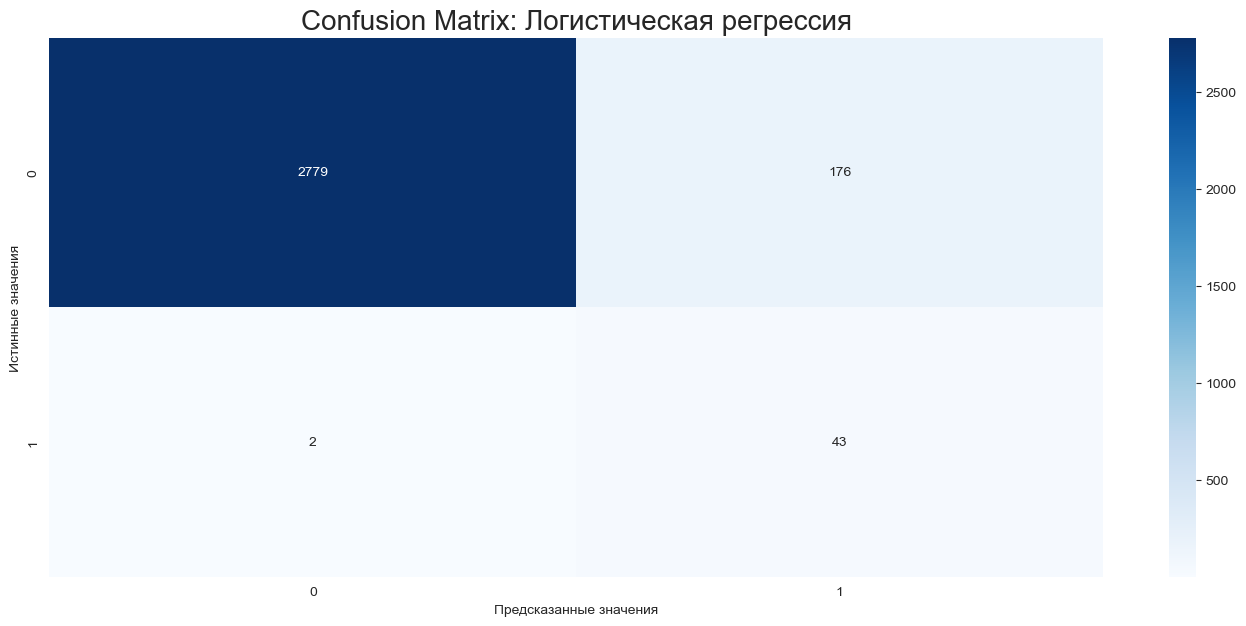

In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_y_pred)
plt.figure(figsize=(17, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Логистическая регрессия', fontsize=20)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

## 2.2 Unsupervised Anomaly Detection
---
Как и во всех алгоритмах машинного обучения без учителя, у нас нет значений целевой переменной. Модель сама будет искать аномалии в данных.

Варианты алгоритмов:
1. **Isolation Forest** - Случайная изоляция по признакам, где аномалии - точки, которые изолировались быстрее всего.
2. **Local Outlier Factor** - Сравнивает плотность точки с её соседней. Если вокруг точки плотность ниже - это аномалия.
3. **DBSCAN** - Кластеризация без указания числа кластеров, точка без кластера - аномалия.
4. **EllipticEnvelope** - Обнаружение выбросов в гауссовских данных (нормальное распределение).

> Буду использовать EllipticEnvelope

### 2.2.0 Elliptic Envelope

Это классический метод поиска аномалий, основанный на предположении, что наши нормальные данные имеют многомерное гауссовское (нормальное) распределение. Он строит эллипс вокруг основного облака точек. Все, что оказывается внутри эллипса - нормальные данные, а все, что снаружи - аномалии.

### Математический подход
1. Оценка параметров: По данным вычисляется вектор средних значений $\mu$ (центр эллипса) и ковариационная матрица $\Sigma$ (форма, наклон и размеры эллипса).
2. Расстояние Махаланобиса: Для каждой точки $x$ считается расстояние до центра с учетом формы облака точек: $$D_M(x) = \sqrt{ (x - \mu)^T \Sigma^{-1} (x - \mu) }$$
3. Граница отсечения: Точки с очень большим расстоянием Махаланобиса (низкой плотностью вероятности) объявляются аномалиями.

### Параметр `contamination` или загрязнение
Этот параметр жестко задает размеры эллипса. Если `contamination=0.01`, алгоритм настроит эллипс так, чтобы ровно 1% точек с самыми плохими показателями остался снаружи.

### 2.2.1 Обработка данных и масштабирование признаков

In [23]:
from sklearn.preprocessing import StandardScaler

numeric_cols = ['amount', 'transaction_hour', 'device_trust_score',
                'velocity_last_24h', 'cardholder_age']

scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])
X

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,cat_Electronics,cat_Food,cat_Grocery,cat_Travel
0,-0.147193,1.503345,0,0,0.195528,0.691873,-0.231580,True,False,False,False
1,1.382879,-1.241383,1,0,1.172909,-0.704299,1.370727,False,False,False,True
2,0.700481,0.781048,0,0,-0.595686,-0.704299,1.170439,False,False,True,False
3,0.398897,-1.096923,0,1,0.474779,0.691873,-0.632157,False,False,True,False
4,-0.972583,0.492130,0,0,0.800573,-1.402386,0.035471,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,1.024158,1.503345,0,0,1.731413,1.389960,-0.431869,False,True,False,False
9996,1.152710,-0.952464,0,0,0.381695,0.691873,-1.233022,False,False,False,False
9997,1.361143,1.358886,0,0,-0.828396,-0.006213,0.102234,True,False,False,False
9998,-0.084458,-1.385842,0,0,-1.107648,-1.402386,-0.431869,True,False,False,False


### 2.2.2 Создание и обучение модели

In [24]:
from sklearn.covariance import EllipticEnvelope

ee_model = EllipticEnvelope(contamination=0.015, random_state=42)
ee_model.fit(X);

### 2.2.3 Оценка результатов

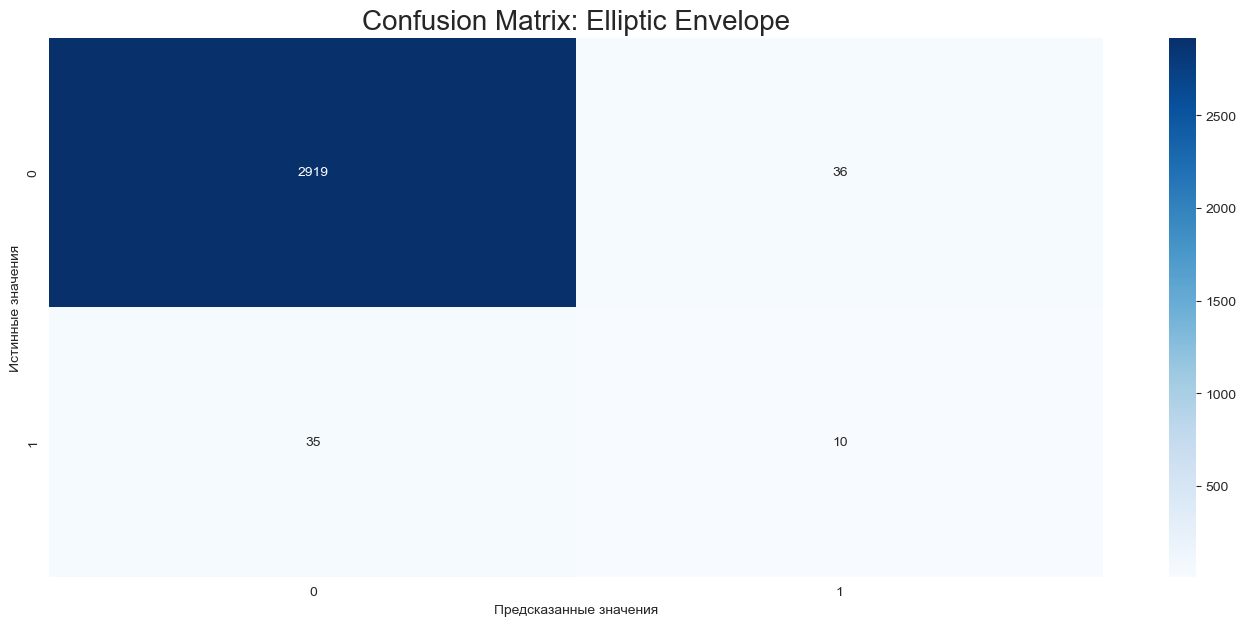

In [25]:
from sklearn.metrics import confusion_matrix

ee_y_pred = ee_model.predict(X_test)

cm = confusion_matrix(y_test, np.where(ee_y_pred == -1, 1, 0))
plt.figure(figsize=(17, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Elliptic Envelope', fontsize=20)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()

## 2.3 Semi-Supervised Anomaly Detection
---
Используем только **Нормальные** данные (`is_fraud = 0`). Всё, что отклоняется от нормы - аномалия.

Варианты алгоритмов:
1. **One-Class SVM** - Строит гиперсферу/гиперплоскость, охватывающую нормальные точки. Все точки вне границы - аномалии.
2. **Isolation Forest (Обученный только на норме)** - Тот же Isolation Forest.
3. **Gaussian Mixture Model (GMM)** - Моделирует распределение нормальных данных. Точки с низкой вероятностью - аномалии.

> Буду использовать Isolation Forest

### 2.3.1 Обработка данных

In [26]:
X_train_normal = X_train[y_train == 0]
X_train_normal

,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,cat_Electronics,cat_Food,cat_Grocery,cat_Travel
4343,0.935386,0.781048,0,0,0.754031,-0.704299,0.168997,False,True,False,False
2143,-0.325206,-0.808005,0,0,-0.781854,-0.704299,1.571016,True,False,False,False
9844,-1.231158,0.203211,0,0,-1.340358,1.389960,0.035471,False,False,False,False
8510,-0.819406,1.503345,1,0,-0.269892,0.691873,-0.231580,False,True,False,False
1379,0.386082,1.069967,1,0,0.986741,0.691873,-1.433311,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
4721,-1.834450,1.214427,0,0,-0.176808,0.691873,-0.498631,False,False,False,False
3698,1.294931,1.069967,0,0,0.986741,2.786132,1.571016,False,False,False,True
860,0.804614,-0.952464,0,0,-0.735312,-0.704299,0.436048,False,False,True,False
7359,1.078566,0.492130,1,0,0.660947,-0.704299,-0.765683,False,True,False,False


### 2.3.2 Создание и обучение модели

In [27]:
from sklearn.ensemble import IsolationForest

if_model = IsolationForest(
    contamination=0.015, # Доля аномалий
    random_state=42,
    n_estimators=100, # Кол-во деревьев
    max_samples=100, # Размер подвыборки
    bootstrap=False, # Без бутстрапа
)

if_model.fit(X_train_normal);

### 2.3.3 Оценка результатов

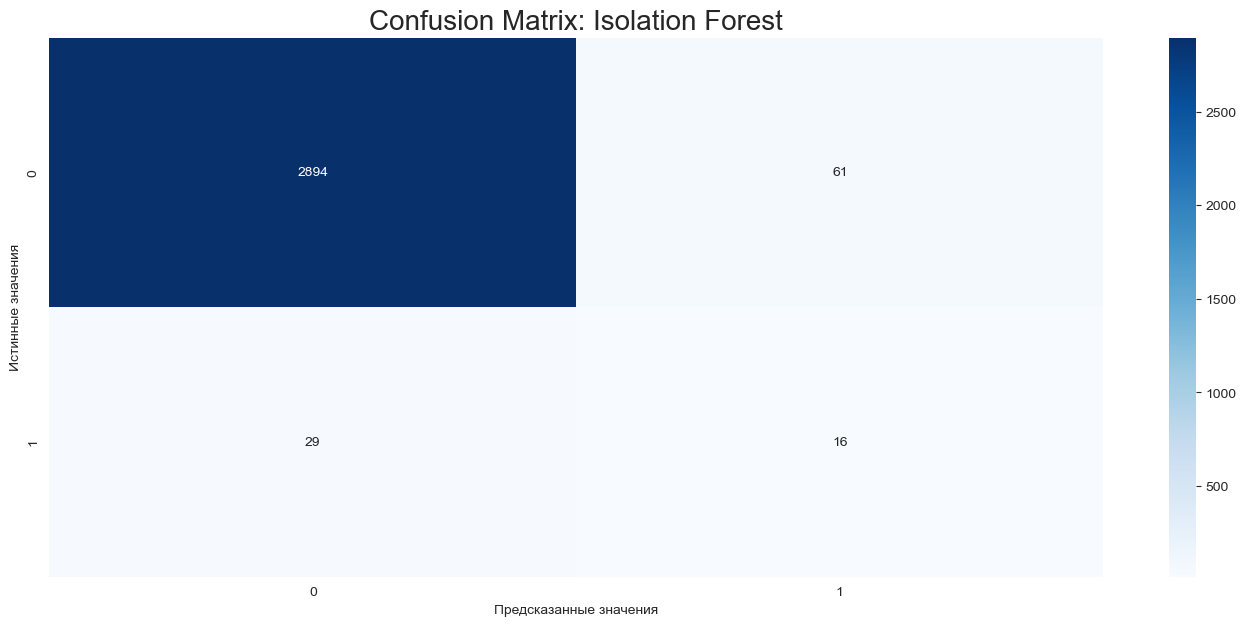

In [28]:
from sklearn.metrics import confusion_matrix

if_y_pred = if_model.predict(X_test)

cm = confusion_matrix(y_test, np.where(if_y_pred == -1, 1, 0))
plt.figure(figsize=(17, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Isolation Forest', fontsize=20)
plt.ylabel('Истинные значения')
plt.xlabel('Предсказанные значения')
plt.show()


## 3. Сравнение моделей

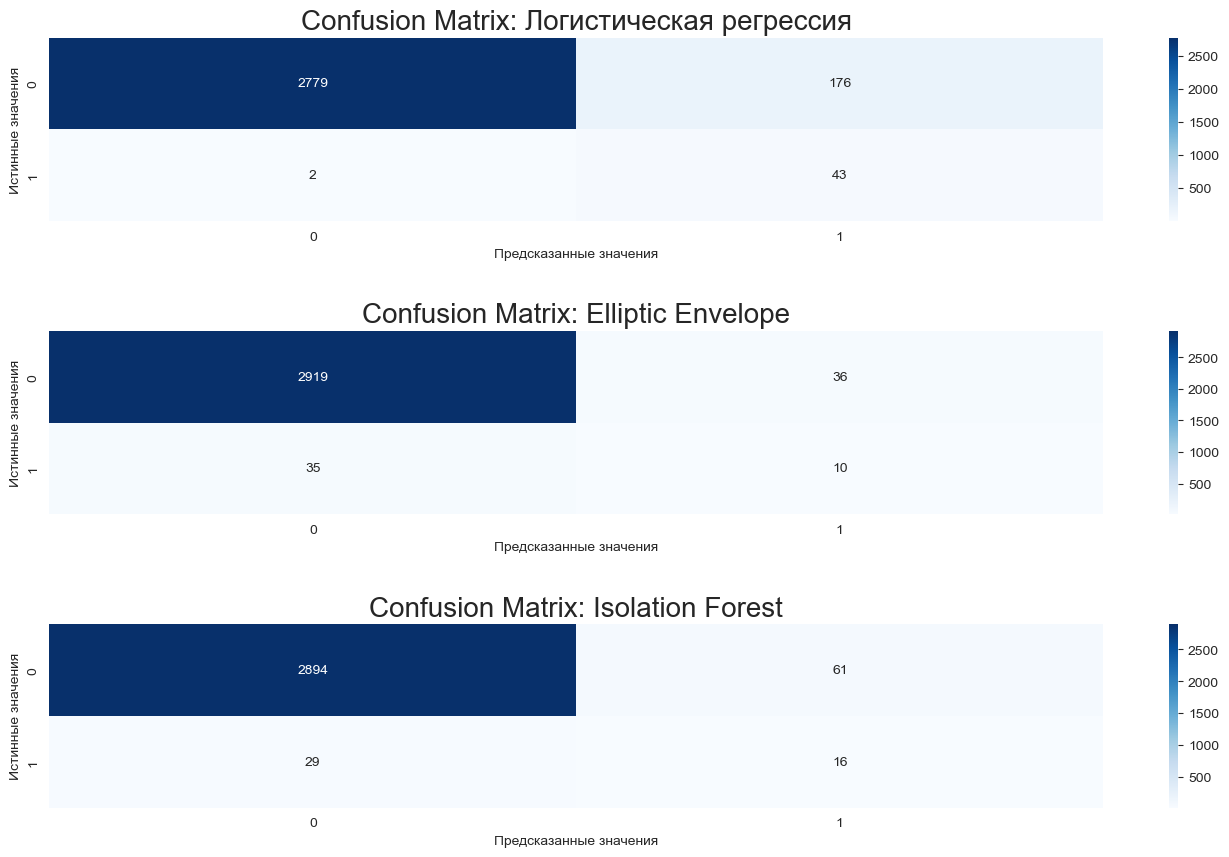

In [29]:
fig, ax = plt.subplots(3, 1, figsize=(17, 10))

cm = confusion_matrix(y_test, lr_y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title('Confusion Matrix: Логистическая регрессия', fontsize=20)
ax[0].set_ylabel('Истинные значения')
ax[0].set_xlabel('Предсказанные значения')


cm = confusion_matrix(y_test, np.where(ee_y_pred == -1, 1, 0))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_title('Confusion Matrix: Elliptic Envelope', fontsize=20)
ax[1].set_ylabel('Истинные значения')
ax[1].set_xlabel('Предсказанные значения')


cm = confusion_matrix(y_test, np.where(if_y_pred == -1, 1, 0))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_title('Confusion Matrix: Isolation Forest', fontsize=20)
ax[2].set_ylabel('Истинные значения')
ax[2].set_xlabel('Предсказанные значения')

fig.subplots_adjust(hspace=0.6)